In [2]:
import torch

Графики для MAE и подобного

In [3]:
dict_no_physics = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/imvp_no_physics.results')
dict_pred_rnn = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/pred_rnn_2.results')
dict_simvp = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/sim_vp.results')
dict_raw_pred = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/predformer_raw.results')
dict_weathergft = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/original_small_mae_2004.results')
dict_single = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/single_block_small_mae_2004.results')
dict_pred_two_o = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/predformer_two_o.results')
dict_imvp_physics = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/imvp_ours.results')

Графики для RMSE и ACC, а так же доверительные интервалы для них все (включая MAE)

In [25]:
dict_no_physics_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/imvp_no_physics_rmse.results') #
dict_pred_rnn_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/pred_rnn_rmse.results') #
dict_simvp_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/sim_vp_rmse.results') #
dict_raw_pred_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/predformer_raw_rmse_2004.results')
dict_weathergft_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/original_small_rmse_2004.results') #
dict_single_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/single_block_small_rmse_2004.results')
dict_pred_two_o_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/predformer_two_o_rmse_2004.results') #
dict_imvp_physics_rmse = torch.load('/home/ebugaev/WeatherPredictions/checkpoints/imvp_ours_long_rmse.results') #

### Графики RMSE

{'mistakes_rmse_list': 60 x 69, 'mistakes_rmse_map': 60 x 69 x H x W, 'rmse_list_all': лист из B x 60 x 69 (для подсчета квантиля cat листа по первому измерению и дальше torch quantile, пример выше), 'mae_list_all': аналогично rmse_list_all но MAE, 'weighted_acc_list': аналогично rmse_list но ACC, 'weighted_acc_all': аналогично rmse_list_all но acc}

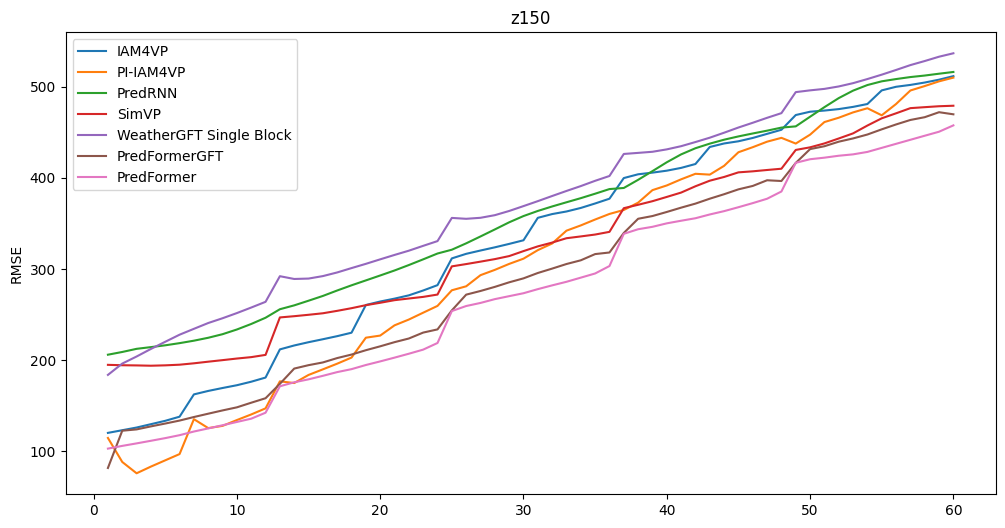

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12,6))
# 4 + 7 -> z500, 17 + 7 -> t500, 43 + 7 -> u500

ids = np.arange(60)  # np.arange(24)


ax.set_title('z150')
ax.set_ylabel('RMSE')
ax.plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='IAM4VP')
ax.plot(ids + 1, dict_imvp_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PI-IAM4VP')
ax.plot(ids + 1, dict_pred_rnn_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredRNN')
ax.plot(ids + 1, dict_simvp_rmse['mistakes_rmse_list'][ids, 4 + 2], label='SimVP')
#ax.plot(ids + 1, dict_weathergft_rmse['mistakes_rmse_list'][ids, 4 + 2], label='WeatherGFT')
ax.plot(ids + 1, dict_single_rmse['mistakes_rmse_list'][ids, 4 + 2], label='WeatherGFT Single Block')
ax.plot(ids + 1, dict_pred_two_o_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredFormerGFT')
ax.plot(ids + 1, dict_raw_pred_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredFormer')

ax.legend()

### Доверительные интервалы, пример для RMSE

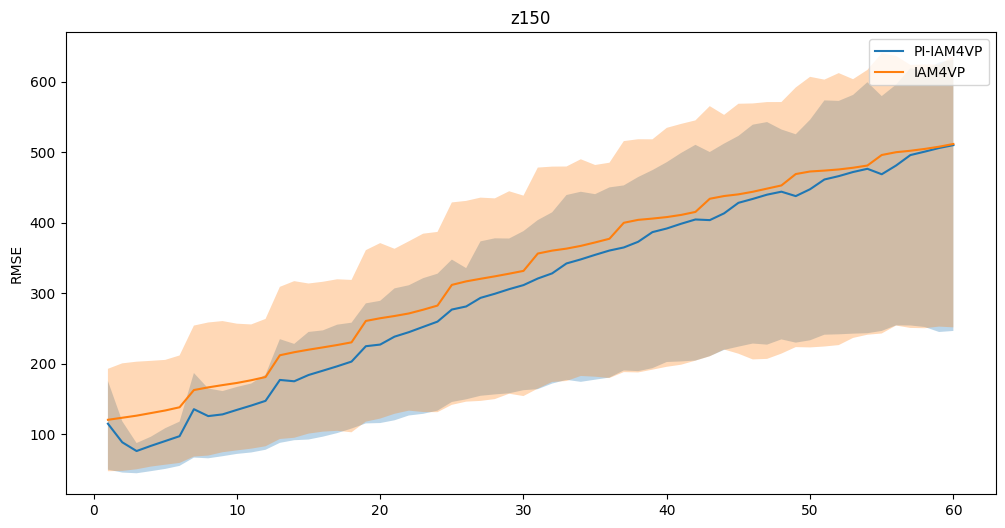

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12,6))
# 4 + 7 -> z500, 17 + 7 -> t500, 43 + 7 -> u500

ids = np.arange(60)  # np.arange(24)


ax.set_title('z150')
ax.set_ylabel('RMSE')
#ax.plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='IAM4VP')

ax.plot(ids + 1, dict_imvp_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PI-IAM4VP')
low = torch.quantile(torch.cat(dict_imvp_physics_rmse['rmse_list_all'], axis=0)[:, :, 4 + 2], 
                                   q=0.05, dim=0, keepdim=False)[ids]
high = torch.quantile(torch.cat(dict_imvp_physics_rmse['rmse_list_all'], axis=0)[:, :, 4 + 2], 
                                   q=0.95, dim=0, keepdim=False)[ids]
ax.fill_between(ids + 1, low, high, alpha=0.3)

ax.plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='IAM4VP')
low = torch.quantile(torch.cat(dict_no_physics_rmse['rmse_list_all'], axis=0)[:, :, 4 + 2], 
                                   q=0.05, dim=0, keepdim=False)[ids]
high = torch.quantile(torch.cat(dict_no_physics_rmse['rmse_list_all'], axis=0)[:, :, 4 + 2], 
                                   q=0.95, dim=0, keepdim=False)[ids]
ax.fill_between(ids + 1, low, high, alpha=0.3)

#ax.plot(ids + 1, dict_pred_rnn_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredRNN')
#ax.plot(ids + 1, dict_simvp_rmse['mistakes_rmse_list'][ids, 4 + 2], label='SimVP')
#ax.plot(ids + 1, dict_weathergft_rmse['mistakes_rmse_list'][ids, 4 + 2], label='WeatherGFT')
#ax.plot(ids + 1, dict_single_rmse['mistakes_rmse_list'][ids, 4 + 2], label='WeatherGFT Single Block')
#ax.plot(ids + 1, dict_pred_two_o_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredFormerGFT')
#ax.plot(ids + 1, dict_raw_pred_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredFormer')

ax.legend()

### All comparison RMSE

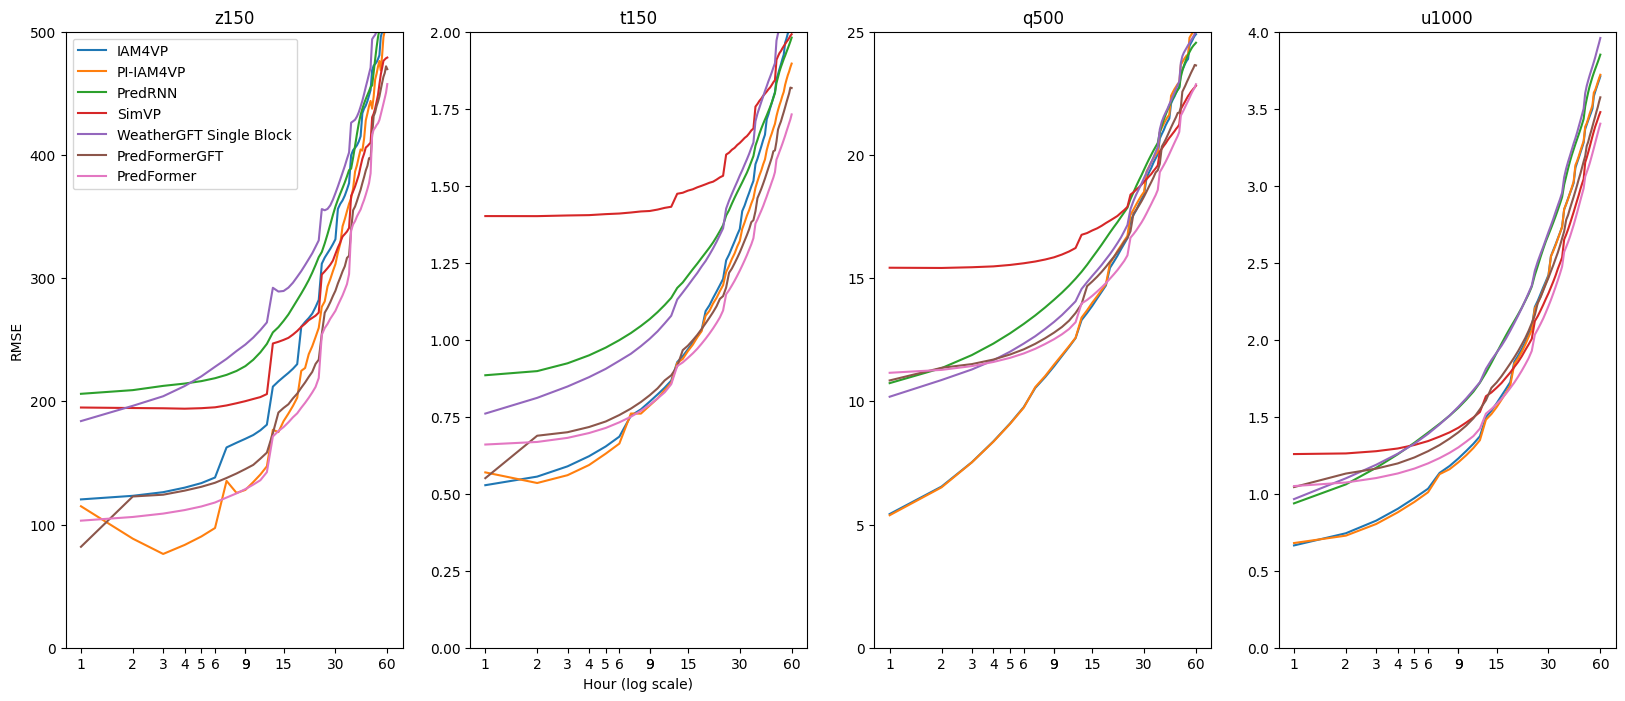

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(1, 4, figsize=(20,8))
# 4 + 7 -> z500, 17 + 7 -> t500, 43 + 7 -> u500

ids = np.arange(60)  # np.arange(24)

ax[0].set_title('z150')
ax[0].set_ylabel('RMSE')
ax[0].plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='IAM4VP')
ax[0].plot(ids + 1, dict_imvp_physics_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PI-IAM4VP')
ax[0].plot(ids + 1, dict_pred_rnn_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredRNN')
ax[0].plot(ids + 1, dict_simvp_rmse['mistakes_rmse_list'][ids, 4 + 2], label='SimVP')
#ax[0].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 4 + 2], label='WeatherGFT')
ax[0].plot(ids + 1, dict_single_rmse['mistakes_rmse_list'][ids, 4 + 2], label='WeatherGFT Single Block')
ax[0].plot(ids + 1, dict_pred_two_o_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredFormerGFT')
ax[0].plot(ids + 1, dict_raw_pred_rmse['mistakes_rmse_list'][ids, 4 + 2], label='PredFormer')
ax[0].set_ylim(0, 500)
ax[0].set_xscale('log')

# Optional: minor ticks for all hours
#ax[0].set_xticks(range(1, 61), minor=True)
#ax[0].grid(which='minor', alpha=0.2)
#ax[0].grid(which='major', alpha=0.5)

ax[1].set_title('t150')
ax[1].set_xlabel('Hour (log scale)')
ax[1].plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 17 + 2], label='IAM4VP')
ax[1].plot(ids + 1, dict_imvp_physics_rmse['mistakes_rmse_list'][ids, 17 + 2], label='PI-IAM4VP')
ax[1].plot(ids + 1, dict_pred_rnn_rmse['mistakes_rmse_list'][ids, 17 + 2], label='PredRNN')
ax[1].plot(ids + 1, dict_simvp_rmse['mistakes_rmse_list'][ids, 17 + 2], label='SimVP')
#ax[1].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 17 + 2], label='WeatherGFT')
ax[1].plot(ids + 1, dict_single_rmse['mistakes_rmse_list'][ids, 17 + 2], label='WeatherGFT Single Block')
ax[1].plot(ids + 1, dict_pred_two_o_rmse['mistakes_rmse_list'][ids, 17 + 2], label='PredFormerGFT')
ax[1].plot(ids + 1, dict_raw_pred_rmse['mistakes_rmse_list'][ids, 17 + 2], label='PredFormer')
ax[1].set_ylim(0, 2)
ax[1].set_xscale('log')

ax[2].set_title('q500')
ax[2].plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 30 + 7], label='IAM4VP')
ax[2].plot(ids + 1, dict_imvp_physics_rmse['mistakes_rmse_list'][ids, 30 + 7], label='PI-IAM4VP')
ax[2].plot(ids + 1, dict_pred_rnn_rmse['mistakes_rmse_list'][ids, 30 + 7], label='PredRNN')
ax[2].plot(ids + 1, dict_simvp_rmse['mistakes_rmse_list'][ids, 30 + 7], label='SimVP')
#ax[2].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 30 + 7], label='WeatherGFT')
ax[2].plot(ids + 1, dict_single_rmse['mistakes_rmse_list'][ids, 30 + 7], label='WeatherGFT Single Block')
ax[2].plot(ids + 1, dict_pred_two_o_rmse['mistakes_rmse_list'][ids, 30 + 7], label='PredFormerGFT')
ax[2].plot(ids + 1, dict_raw_pred_rmse['mistakes_rmse_list'][ids, 30 + 7], label='PredFormer')
ax[2].set_ylim(0, 25)
ax[2].set_xscale('log')

ax[3].set_title('u1000')
ax[3].plot(ids + 1, dict_no_physics_rmse['mistakes_rmse_list'][ids, 43 + 12], label='IAM4VP')
ax[3].plot(ids + 1, dict_imvp_physics_rmse['mistakes_rmse_list'][ids, 43 + 12], label='PI-IAM4VP')
ax[3].plot(ids + 1, dict_pred_rnn_rmse['mistakes_rmse_list'][ids, 43 + 12], label='PredRNN')
ax[3].plot(ids + 1, dict_simvp_rmse['mistakes_rmse_list'][ids, 43 + 12], label='SimVP')
#ax[3].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 43 + 12], label='WeatherGFT')
ax[3].plot(ids + 1, dict_single_rmse['mistakes_rmse_list'][ids, 43 + 12], label='WeatherGFT Single Block')
ax[3].plot(ids + 1, dict_pred_two_o_rmse['mistakes_rmse_list'][ids, 43 + 12], label='PredFormerGFT')
ax[3].plot(ids + 1, dict_raw_pred_rmse['mistakes_rmse_list'][ids, 43 + 12], label='PredFormer')
ax[3].set_ylim(0, 4.0)
ax[3].set_xscale('log')

# Show every 5 hours with all hours from 1-12
major_ticks = [1, 2, 3, 4, 5, 6, 9] + [9, 15, 30, 60]
labels = [str(int(tick)) for tick in major_ticks]

for i in range(4):
    ax[i].minorticks_off() 
    ax[i].set_xticks(major_ticks)
    ax[i].set_xticklabels(labels)
    
    #ax[i].grid(axis='y', 
    #    color='gray', 
    #    linestyle='-', 
    #    linewidth=0.5, 
    #    alpha=0.7)

ax[0].legend()
fig.savefig('all_comparison.png', dpi=150, bbox_inches='tight')
fig.show()

### All comparison ACC

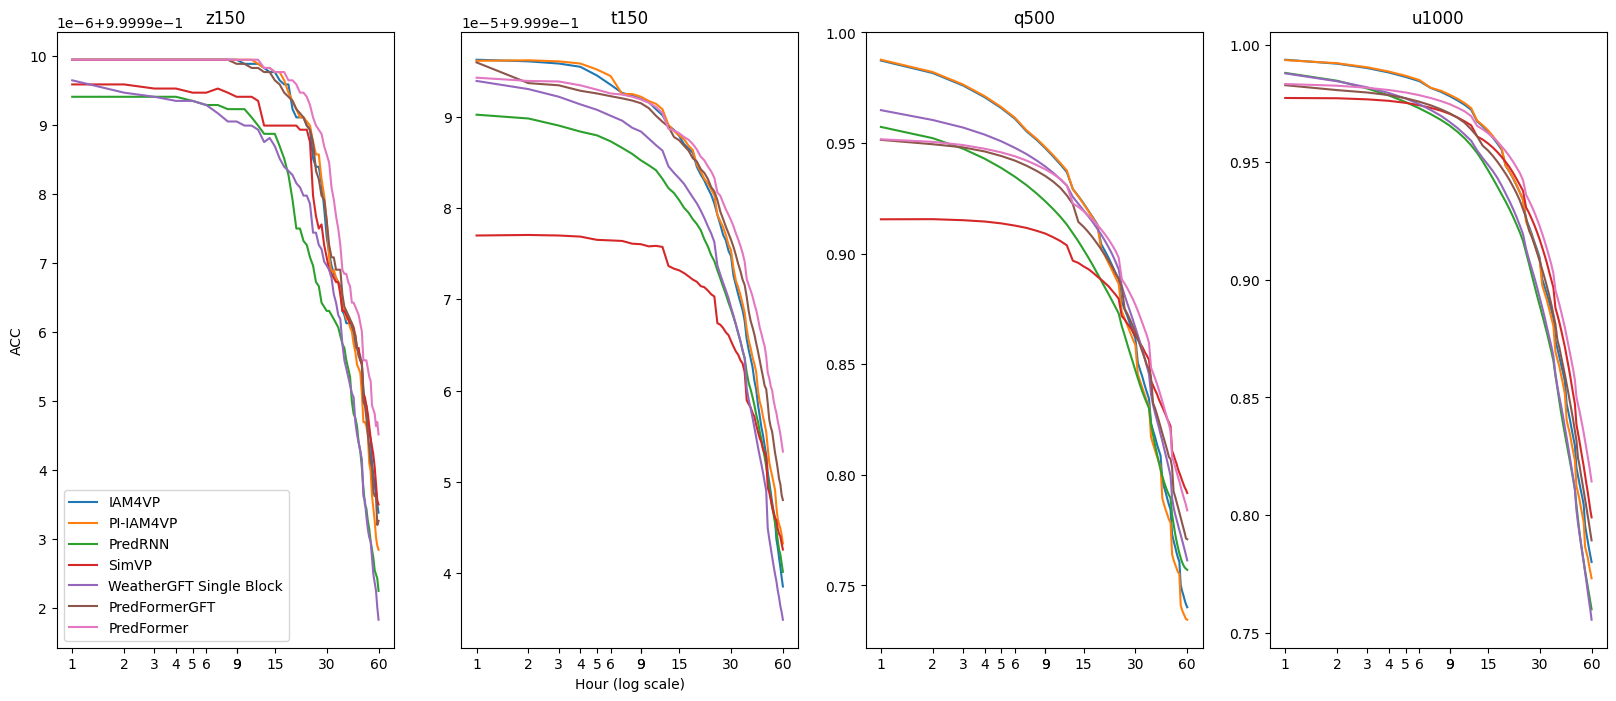

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(1, 4, figsize=(20,8))
# 4 + 7 -> z500, 17 + 7 -> t500, 43 + 7 -> u500

ids = np.arange(60)  # np.arange(24)

ax[0].set_title('z150')
ax[0].set_ylabel('ACC')
ax[0].plot(ids + 1, dict_no_physics_rmse['weighted_acc_list'][ids, 4 + 2], label='IAM4VP')
ax[0].plot(ids + 1, dict_imvp_physics_rmse['weighted_acc_list'][ids, 4 + 2], label='PI-IAM4VP')
ax[0].plot(ids + 1, dict_pred_rnn_rmse['weighted_acc_list'][ids, 4 + 2], label='PredRNN')
ax[0].plot(ids + 1, dict_simvp_rmse['weighted_acc_list'][ids, 4 + 2], label='SimVP')
#ax[0].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 4 + 2], label='WeatherGFT')
ax[0].plot(ids + 1, dict_single_rmse['weighted_acc_list'][ids, 4 + 2], label='WeatherGFT Single Block')
ax[0].plot(ids + 1, dict_pred_two_o_rmse['weighted_acc_list'][ids, 4 + 2], label='PredFormerGFT')
ax[0].plot(ids + 1, dict_raw_pred_rmse['weighted_acc_list'][ids, 4 + 2], label='PredFormer')
#ax[0].set_ylim(0, 500)
ax[0].set_xscale('log')

# Optional: minor ticks for all hours
#ax[0].set_xticks(range(1, 61), minor=True)
#ax[0].grid(which='minor', alpha=0.2)
#ax[0].grid(which='major', alpha=0.5)

ax[1].set_title('t150')
ax[1].set_xlabel('Hour (log scale)')
ax[1].plot(ids + 1, dict_no_physics_rmse['weighted_acc_list'][ids, 17 + 2], label='IAM4VP')
ax[1].plot(ids + 1, dict_imvp_physics_rmse['weighted_acc_list'][ids, 17 + 2], label='PI-IAM4VP')
ax[1].plot(ids + 1, dict_pred_rnn_rmse['weighted_acc_list'][ids, 17 + 2], label='PredRNN')
ax[1].plot(ids + 1, dict_simvp_rmse['weighted_acc_list'][ids, 17 + 2], label='SimVP')
#ax[1].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 17 + 2], label='WeatherGFT')
ax[1].plot(ids + 1, dict_single_rmse['weighted_acc_list'][ids, 17 + 2], label='WeatherGFT Single Block')
ax[1].plot(ids + 1, dict_pred_two_o_rmse['weighted_acc_list'][ids, 17 + 2], label='PredFormerGFT')
ax[1].plot(ids + 1, dict_raw_pred_rmse['weighted_acc_list'][ids, 17 + 2], label='PredFormer')
#ax[1].set_ylim(0, 2)
ax[1].set_xscale('log')

ax[2].set_title('q500')
ax[2].plot(ids + 1, dict_no_physics_rmse['weighted_acc_list'][ids, 30 + 7], label='IAM4VP')
ax[2].plot(ids + 1, dict_imvp_physics_rmse['weighted_acc_list'][ids, 30 + 7], label='PI-IAM4VP')
ax[2].plot(ids + 1, dict_pred_rnn_rmse['weighted_acc_list'][ids, 30 + 7], label='PredRNN')
ax[2].plot(ids + 1, dict_simvp_rmse['weighted_acc_list'][ids, 30 + 7], label='SimVP')
#ax[2].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 30 + 7], label='WeatherGFT')
ax[2].plot(ids + 1, dict_single_rmse['weighted_acc_list'][ids, 30 + 7], label='WeatherGFT Single Block')
ax[2].plot(ids + 1, dict_pred_two_o_rmse['weighted_acc_list'][ids, 30 + 7], label='PredFormerGFT')
ax[2].plot(ids + 1, dict_raw_pred_rmse['weighted_acc_list'][ids, 30 + 7], label='PredFormer')
#ax[2].set_ylim(0, 25)
ax[2].set_xscale('log')

ax[3].set_title('u1000')
ax[3].plot(ids + 1, dict_no_physics_rmse['weighted_acc_list'][ids, 43 + 12], label='IAM4VP')
ax[3].plot(ids + 1, dict_imvp_physics_rmse['weighted_acc_list'][ids, 43 + 12], label='PI-IAM4VP')
ax[3].plot(ids + 1, dict_pred_rnn_rmse['weighted_acc_list'][ids, 43 + 12], label='PredRNN')
ax[3].plot(ids + 1, dict_simvp_rmse['weighted_acc_list'][ids, 43 + 12], label='SimVP')
#ax[3].plot(ids + 1, dict_weathergft['mistakes_list'][ids, 43 + 12], label='WeatherGFT')
ax[3].plot(ids + 1, dict_single_rmse['weighted_acc_list'][ids, 43 + 12], label='WeatherGFT Single Block')
ax[3].plot(ids + 1, dict_pred_two_o_rmse['weighted_acc_list'][ids, 43 + 12], label='PredFormerGFT')
ax[3].plot(ids + 1, dict_raw_pred_rmse['weighted_acc_list'][ids, 43 + 12], label='PredFormer')
#ax[3].set_ylim(0, 4.0)
ax[3].set_xscale('log')

# Show every 5 hours with all hours from 1-12
major_ticks = [1, 2, 3, 4, 5, 6, 9] + [9, 15, 30, 60]
labels = [str(int(tick)) for tick in major_ticks]

for i in range(4):
    ax[i].minorticks_off() 
    ax[i].set_xticks(major_ticks)
    ax[i].set_xticklabels(labels)
    
    #ax[i].grid(axis='y', 
    #    color='gray', 
    #    linestyle='-', 
    #    linewidth=0.5, 
    #    alpha=0.7)

ax[0].legend()
fig.savefig('all_comparison_acc.png', dpi=150, bbox_inches='tight')
fig.show()